In [3]:
pip install mlflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Petar\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [4]:
!pip install timm


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Petar\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import torch
import os
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import torch.nn as nn
import mlflow
from tqdm import tqdm
import numpy as np
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import timm
from peft import LoraConfig, get_peft_model, PeftModel
import torch.optim as optim
import seaborn as sns
import math

# Fine-Tuning ConvNeXt-V2 for Chest X-Ray Diagnosis

The classification of chest X-rays (CXR) is a highly complex task due to the variety of possible overlapping findings, many of which follow a long-tailed distribution. Some lung conditions are exceptionally rare, yet their accurate and early detection is crucial in real-world clinical practice.
This project focuses on the multi-label classification of 14 distinct lung pathologies using the **NIH ChestX-ray14** dataset https://www.kaggle.com/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized . Some lung conditions are exceptionally rare.
To handle the challenges efficiently, this project explores and compares two distinct phases of parameter-efficient fine-tuning on ConvNeXt-V2, a state-of-the-art vision backbone:
* Phase 1, Model V1
  First we integrate Low-Rank Adaptation (LoRA) strictly into the standard linear layers (mlp.fc1 and mlp.fc2) to establish a baseline for low-overhead medical adaptation.
* Phase 2, Model V2
In the second stage, we expand the structural focus of the network by injecting LoRA matrices directly into the deep depthwise convolutional layers - dwconv alongside the linear blocks, allowing the model to simultaneously tune its visual spatial filters for clinical anomalies. \

Multi-label classification which means that images can have multiple pathologies simultaneously.
There are 14 classes:
* Infiltration
* Effusion
* Atelectasis
* Nodule
* Mass
* Pneumothorax
* Consolidation 
* Pleural_Thickening   
* Cardiomegaly          
* Emphysema   
* Edema  
* Fibrosis    
* Pneumonia  
* Hernia


## Work flow
The workflow consists of the following key steps:
1. Data Processing \
Processing medical images and extracting labels from the dataset metadata, automatically handling complex strings
2. Multi-Label encoding\
Each patient's record is transformed into a fixed-size binary tensor of length 14, where each position represents a specific lung condition:
* A value of 1.0 indicates a presence of the pathology
* A value of 0.0 indicates a healthy condition regarding that specific pathology

3. Data stratification \
 Medical multi-label datasets cannot be split using standard random sampling because rare diseases could accidentally end up entirely in the validation set, leaving the training set with zero positive examples. To ensure absolute clinical validity, the dataset is split strictly based on unique patient identifiers. Randomly splitting images would leak a patient's unique data into the validation set, creating artificially high scores. To prevent this data leakage, we extract all unique patient IDs, randomize them with a fixed seed (42) for reproducibility, and split them into 80% training, 10% validation, and 10% testing groups. Finally, we map these IDs back to the images, generating independent subsets containing exactly 89,794 training, 10,644 validation, and 11,682 testing records.
4.  Image Preprocessing & Augmentation \
Тhe dataset images were pre-downloaded and optimized directly at a fixed 224 × 224 resolution. The images pixel intensities are standardly normalized using ImageNet constants to ensure stable initial gradient steps. To improve model robustness against minor clinical variations, standard data augmentations such as random horizontal flips and rotations are applied to the training set
The dataset images were pre-downloaded and optimized directly at a fixed 224 × 224 resolution. To stabilize the initial backpropagation gradients, pixel intensities are normalized using the standard ImageNet channel constants `mean` and `std`. To improve model robustness against minor clinical variations, data augmentations are applied strictly to the training set. This includes spatial transformations such as `RandomHorizontalFlip`, `RandomRotation(15)`, and a `RandomResizedCrop(224)` that dynamically scales random sub-regions (80% to 100%) to simulate varying chest positions and distances under the X-ray scanner.
5. Custom dataset implementation \
We create a custom PyTorch dataset to load our images and labels. Instead of loading all heavy image files into the computer's memory at once, this module reads each image from the disk one by one during training. This approach is highly efficient and prevents the system from crashing. For every patient, the code automatically converts the image into numbers, applies our processing transformations, and packages everything into a simple dictionary containing `pixel_values` and `labels` ready for the batch loaders.
6. Base Model - ConvNextV2 \
We load it with `pretrained = True`. This means the model has already been trained on millions of images before. It already knows how to recognize shapes, borders, and textures. Using a pre-trained model is very helpful because it saves us training time.
7. LoRA configuration, phase 1 \
To adapt this model without changing all of its 90 million numbers, we use Hugging face's `peft` library. In this first phase we setup a LoraConfig with a rank ($r = 16$) and Alpha ($\alpha = 32$). We target only the standard linear layers (`mlp.fc1` and `mlp.fc2`). This locks the original model completely and trains only a very small group of new adapters.
8. MLflow tracking setup
This system saves our settings, monitors the training loss, logs our validation AUC-ROC scores at each step, and saves the best model files directly to the computer.
9. Model training \
The model is optimized using the AdamW optimizer with a learning rate $lr = 0.0001$. We handle the severe class imbalance problem inherent in medical data by utilizing a weighted binary cross-entropy loss function ($BCEWithLogitsLoss$) enhanced with a custom $pos\_weight$ tensor.

For a single pathology, the loss value ($L$) for a single patient is calculated using the following formula:
$$L = - \left[ p \cdot y \cdot \log(\sigma(x)) + (1 - y) \cdot \log(1 - \sigma(x)) \right]$$

Where:
* **$x$** (The Logit): The raw numeric output score generated by our ConvNeXt-V2 model.
* **$\sigma(x)$** (The Sigmoid function): Mathematically defined as $\sigma(x) = \frac{1}{1 + e^{-x}}$. It converts the raw score $x$ into a continuous confidence score between 0.0 and 1.0 (representing $0\%$ to $100\%$ model certainty).
* **$y$** (The Actual Truth): The ground truth label from the doctor. It is 1 if the patient has the disease, and 0 if the patient is healthy.
* **$p$** (The pos_weight): Our custom balance weight factor calculated for that specific disease to fight class imbalance.

The loss function dynamically separates the optimization process into two mutually exclusive terms based on the ground truth indicator variable ($y$):

* When the patient has the disease ($y = 1$): The right-hand complement term $(1 - y)$ becomes zero and is mathematically eliminated. The formula simplifies to:
$$L = - p \cdot \log(\sigma(x))$$
The optimization logic here is that if the network assigns a low confidence score (e.g., $0.05$) to a true positive case, the $\log$ function exponentially penalizes this hesitation, resulting in a high loss value. Conversely, as the model's confidence approaches $1.0$ ($100\%$ certainty), the loss converges toward zero. Because positive examples of rare conditions are scarce, the loss is multiplied by the positive class weight scalar ($p > 1$) to heavily amplify the penalty for missing a disease.

* When the patient is healthy ($y = 0$): The primary target term is nullified via the $y$ multiplier. The objective function reduces to:
$$L = - \log(1 - \sigma(x))$$
In this case, the loss function strictly penalizes the model for false positives. The loss approaches zero only when the network's confidence successfully converges to $0.0$ ($0\%$ probability of disease), ensuring that healthy cases are correctly identified as negative.

10. Second experiment \
To improve the model's learning process, we introduce a second experimental phase. In this step, we add the deep depthwise convolutional blocks (`"dwconv"`) to our target list, which helps the network see fine medical details and lung textures much better. To give the model more capacity to learn, we increase the LoRA Rank to 32 and Alpha to 64, while keeping a stable and safe learning rate of 0.0001.
11. Learning Curves
12. Model test\
We evaluate the model from our second experiment on the independent test dataset. We use a **Classification report** and a visual heatmap to check the results for each individual disease.
13. Evaluation and Visualization
* Confusion matrix
* Confusion matrix Visualization
* Qualitative evaluation: Visual examples
* Saliency maps
* Quantitative error analysis
* Confidence distribution analysis
14. Conclusion

In [6]:
data_entry = pd.read_csv("Data_Entry_2017.csv")

In [7]:
data_entry.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,058Y,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,058Y,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,058Y,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,081Y,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,081Y,F,PA,2582,2991,0.143,0.143,NaN


In [8]:
data_entry["Finding Labels"].str.split('|').explode().unique()

array(['Cardiomegaly', 'Emphysema', 'Effusion', 'No Finding', 'Hernia',
       'Infiltration', 'Mass', 'Nodule', 'Atelectasis', 'Pneumothorax',
       'Pleural_Thickening', 'Pneumonia', 'Fibrosis', 'Edema',
       'Consolidation'], dtype=object)

In [9]:
unique_labels = data_entry["Finding Labels"].str.split('|').explode().unique()

In [10]:
diseases = [l for l in unique_labels if l != 'No Finding']

In [11]:
len(diseases)

14

In [12]:
#encoding labels
for label in diseases:
    data_entry[label] = data_entry['Finding Labels'].str.contains(label, regex = False).astype(int)

In [13]:
count_classes = data_entry[diseases].sum().sort_values(ascending = False)

In [14]:
(count_classes / len(data_entry) * 100).sort_values(ascending = False)

Infiltration          17.722083
Effusion              11.868534
Atelectasis           10.288084
Nodule                 5.639493
Mass                   5.124866
Pneumothorax           4.725294
Consolidation          4.162504
Pleural_Thickening     3.019087
Cardiomegaly           2.472351
Emphysema              2.244024
Edema                  2.054049
Fibrosis               1.503746
Pneumonia              1.206743
Hernia                 0.202462
dtype: float64

In [15]:
(((data_entry['Finding Labels'] == 'No Finding').sum()) /  len(data_entry)) * 100

np.float64(53.88155547627542)

In [16]:
healthy_patients = data_entry[data_entry['Finding Labels'] == 'No Finding']

In [17]:
healthy_patients.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,...,Infiltration,Mass,Nodule,Atelectasis,Pneumothorax,Pleural_Thickening,Pneumonia,Fibrosis,Edema,Consolidation
3,00000002_000.png,No Finding,0,2,081Y,M,PA,2500,2048,0.171,...,0,0,0,0,0,0,0,0,0,0
13,00000005_000.png,No Finding,0,5,069Y,F,PA,2048,2500,0.168,...,0,0,0,0,0,0,0,0,0,0
14,00000005_001.png,No Finding,1,5,069Y,F,AP,2500,2048,0.168,...,0,0,0,0,0,0,0,0,0,0
15,00000005_002.png,No Finding,2,5,069Y,F,AP,2500,2048,0.168,...,0,0,0,0,0,0,0,0,0,0
16,00000005_003.png,No Finding,3,5,069Y,F,PA,2992,2991,0.143,...,0,0,0,0,0,0,0,0,0,0


In [18]:
print(data_entry[data_entry['Finding Labels'].str.contains('|', regex=False)]['Finding Labels'].head(10))

1                                Cardiomegaly|Emphysema
2                                 Cardiomegaly|Effusion
7                                   Hernia|Infiltration
12                                          Mass|Nodule
20                                Effusion|Infiltration
37                                        Effusion|Mass
39                               Emphysema|Pneumothorax
40                               Emphysema|Pneumothorax
42         Effusion|Emphysema|Infiltration|Pneumothorax
43    Emphysema|Infiltration|Pleural_Thickening|Pneu...
Name: Finding Labels, dtype: object


### Data stratification

In [19]:
unique_ids = torch.tensor(data_entry["Patient ID"].unique())

In [20]:
#guarantee reproducibility
torch.manual_seed(42)

In [21]:
shuffled_indices = torch.randperm(len(unique_ids))

In [22]:
unique_ids = unique_ids[shuffled_indices].tolist()

In [23]:
split_train = int(len(unique_ids) * 0.8)
split_val = int(len(unique_ids) * 0.9)

In [24]:
train_ids = unique_ids[:split_train]
val_ids = unique_ids[split_train:split_val]
test_ids = unique_ids[split_val:]

In [25]:
train = data_entry[data_entry["Patient ID"].isin(train_ids)].sample(frac = 1, random_state = 42).reset_index(drop = True)
val = data_entry[data_entry["Patient ID"].isin(val_ids)].sample(frac = 1, random_state = 42).reset_index(drop = True)
test = data_entry[data_entry["Patient ID"].isin(test_ids)].sample(frac = 1, random_state = 42).reset_index(drop = True)

In [26]:
len(train), len(val), len(test)

(89794, 10644, 11682)

### Image preprocessing

Initialize standard PyTorch transformations for data preprocessing and normalization. Since the chest X-ray images are pre-resized to 224x224 pixels, the pipeline converts the images into numerical tensors and applies standard normalization using specific channel mean and standard deviation values. This calibration ensures that the input pixel distributions match the expected format required by the pretrained ConvNeXt-V2 backbone layers.

In [27]:
#data augmentation
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale = (0.8, 1.0)),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees = 0, translate = (0.05, 0.05))
])

In [28]:
normalize_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
])

In [29]:
#custom dataset for loading images and multi-label tags
class ChestXrayDataset(Dataset):
    def __init__(self, dataset, img_dir, diseases, transform = None):
        self.dataset = dataset
        self.img_dir = img_dir
        self.diseases = diseases
        self.transform = transform #for augmentation

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img_name = self.dataset.iloc[idx]['Image Index']
        img_path = os.path.join(self.img_dir, img_name)
    
        image = Image.open(img_path).convert('RGB')
        if self.transform is not None: 
            image = self.transform(image)



        pixel_values = normalize_transform(image)
    
        labels_list = self.dataset.iloc[idx][self.diseases].values.astype('float32')
        labels_tensor = torch.tensor(labels_list, dtype=torch.float32)
    
        return {
            'pixel_values': pixel_values,
            'labels': labels_tensor
        }

In [30]:
train_dataset = ChestXrayDataset(dataset = train, img_dir = 'images-224/images-224', diseases = diseases, transform = train_transforms)

In [31]:
val_dataset = ChestXrayDataset(dataset = val, img_dir = 'images-224/images-224', diseases = diseases, transform = None)

In [32]:
test_dataset = ChestXrayDataset(dataset = test, img_dir = 'images-224/images-224', diseases = diseases, transform = None)

In [33]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True, num_workers = 0, pin_memory = True)
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle = False, num_workers = 0, pin_memory = True)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False, num_workers = 0, pin_memory = True)

In [34]:
sample_dataset = next(iter(train_loader))

In [35]:
sample_rows = train.head(4)

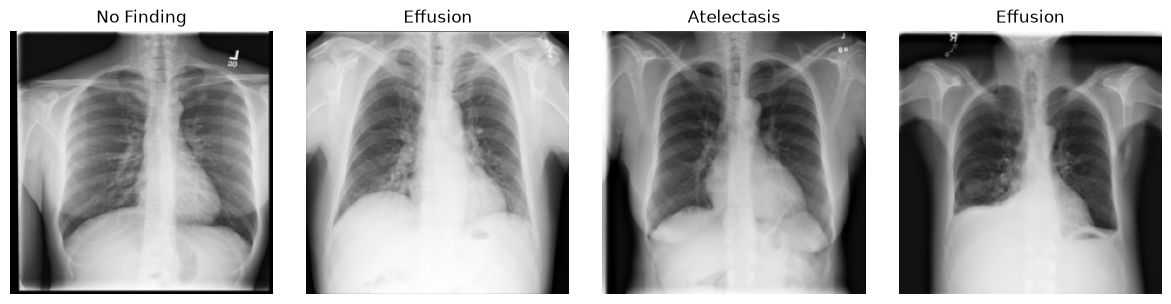

In [36]:
fig, axes = plt.subplots(1, 4, figsize = (12, 3))
for i, ax in enumerate(axes):
    img_name = sample_rows.iloc[i]['Image Index']
    img_path = os.path.join('images-224/images-224', img_name)
    raw_img = Image.open(img_path)
    
    ax.imshow(raw_img, cmap='gray')
    ax.set_title(sample_rows.iloc[i]['Finding Labels'])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [38]:
device

device(type='cuda')

### Class imbalance assessment

Calculate negative-to-positive ratio for each of the 14 pathologies to fix the problem with unbalanced 
* positive - diseases
* negative - healthy cases

In [39]:
positive_weights = []
for disease in diseases:
    positive = train[disease].sum()
    negative = len(train) - positive
    positive_weights.append(negative / (positive + 0.00001)) #add 0.00001 to prevent zero divide 

In [40]:
#We transform the list into a tensor because pytorch requires this format for calculation
weights_tensor = torch.tensor(positive_weights, dtype = torch.float32)

In [41]:
#apply sqrt scaling to the weights in order to minimize extremely high values
weights_tensor = torch.sqrt(weights_tensor)

In [42]:
print(weights_tensor)

tensor([ 6.2038,  6.6086,  2.7197, 21.5466,  2.1474,  4.3747,  4.1467,  2.9619,
         4.5065,  5.6991,  8.9384,  8.1806,  6.8796,  4.8089])


We observe a huge class imbalance across the 14 pathologies. We will apply these values in the loss function (BCEWithLogitsLoss) as positive weight (when there is а disease case). This ensures the model is penalized more heavily when it misses rare diseases.

## Load Base Model

In [43]:
#load the official base ConvNext Model
base_model = timm.create_model('convnextv2_base', pretrained = True, num_classes = 14)

### Low-Rank Adaptation Configuration

In [44]:
lora_config = LoraConfig(
    r = 16,
    lora_alpha = 32,
    target_modules = ["mlp.fc1", "mlp.fc2"], 
    lora_dropout = 0.1,
    bias = "none",
    modules_to_save = ["head.fc"]
)

In [45]:
model = get_peft_model(base_model, lora_config)

In [46]:
model.print_trainable_parameters()

trainable params: 2,902,030 || all params: 90,609,180 || trainable%: 3.2028


We freeze the big model and insert tiny trainable matrices using Hugging Face PEFT library.
* r = 16 (rank) id the size of our trainable layers
* lora_alpha = 32 is a scaling factor that balances the power between our new LoRA weights and the frozen base model
* lora_dropout is for preventing the model from overfitting
* ["mlp.fc1", "mlp.fc2"] - we place LoRA adapters inside the MLP layers of the ConvNeXt blocks. This updates how the model processes chest textures without breaking its fundamental vision
* ["head.fc"] - the original model was trained for 1000 everyday objects (dogs, cars). We completely replace the final layer with a new classification head for our 14 specific medical diseases


In [47]:
model.to(device)

PeftModel(
  (base_model): LoraModel(
    (model): ConvNeXt(
      (stem): Sequential(
        (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
        (1): LayerNorm2d((128,), eps=1e-06, elementwise_affine=True)
      )
      (stages): Sequential(
        (0): ConvNeXtStage(
          (downsample): Identity()
          (blocks): Sequential(
            (0): ConvNeXtBlock(
              (conv_dw): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128)
              (norm): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
              (mlp): GlobalResponseNormMlp(
                (fc1): lora.Linear(
                  (base_layer): Linear(in_features=128, out_features=512, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.1, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=128, out_features=16, bias=False)
                  )
 

## ML flow integration

In [48]:
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

In [49]:
mlflow.set_tracking_uri("file:./mlruns_fine_tuning_convnext_chest_xray")

In [50]:
mlflow.set_experiment("Fine-Tuning ConvNeXt-V2 Chest X Ray")

<Experiment: artifact_location=('file:C:/Users/Petar/Desktop/New folder/Deep '
 'learning/Project/mlruns_fine_tuning_convnext_chest_xray/758397728355982535'), creation_time=1787504782250, effective_trace_archival_retention=None, experiment_id='758397728355982535', last_update_time=1787504782250, lifecycle_stage='active', name='Fine-Tuning ConvNeXt-V2 Chest X Ray', tags={}, trace_location=None, workspace='default'>

In [51]:
model = model.to(device)

## Model training and optimization

In [52]:
def train_model(model, train_loader, val_loader, optimizer, epochs, run_name):
    criterion = nn.BCEWithLogitsLoss(pos_weight = weights_tensor.to(device))
    best_auc = 0.0

    with mlflow.start_run(run_name = run_name):
        mlflow.log_param("epochs", epochs)
        mlflow.log_param("batch_size", train_loader.batch_size)
        mlflow.log_param("model_architecture", "ConvNeXt-V2-Base-LoRA")
        mlflow.log_param("loss_function", "BCEWithLogitsLoss")

        for epoch in range(epochs):
            print(f"\nEpoch {epoch + 1}/{epochs}")

            model.train()
            train_loss = 0.0
            all_train_labels = []
            all_train_outputs = []

            pbar = tqdm(train_loader, desc = f"Epoch {epoch + 1} - Training", leave = True)
            for batch in pbar:
                inputs = batch['pixel_values'].to(device)
                labels = batch['labels'].to(device).float()
                
                optimizer.zero_grad()
                
                outputs = model(inputs)
                if hasattr(outputs, "logits"):
                    outputs = outputs.logits
                    
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                
                train_loss += loss.item() * inputs.size(0)
                all_train_labels.append(labels.cpu().numpy())
                all_train_outputs.append(torch.sigmoid(outputs).detach().cpu().numpy())
                pbar.set_postfix({'loss': f"{loss.item():.4f}"})

            epoch_train_loss = train_loss / len(train_loader.dataset)
            all_train_labels = np.vstack(all_train_labels)
            all_train_outputs = np.vstack(all_train_outputs)
            epoch_train_auc = roc_auc_score(all_train_labels, all_train_outputs, average = "macro")

            model.eval()
            val_loss = 0.0

            all_labels = []
            all_outputs = []

            with torch.no_grad():
                for batch in val_loader:
                    inputs = batch['pixel_values'].to(device)
                    labels = batch['labels'].to(device).float()
                    
                    outputs = model(inputs)
                    if hasattr(outputs, "logits"):
                        outputs = outputs.logits
                    
                    loss = criterion(outputs, labels)
                    val_loss += loss.item() * inputs.size(0)

                    all_labels.append(labels.cpu().numpy())
                    all_outputs.append(torch.sigmoid(outputs).detach().cpu().numpy())

            epoch_val_loss = val_loss / len(val_loader.dataset)
            all_labels = np.vstack(all_labels)
            all_outputs = np.vstack(all_outputs)

            epoch_val_auc = roc_auc_score(all_labels, all_outputs, average = "macro")

            print(f"Train Loss: {epoch_train_loss:.4f} | Train AUC: {epoch_train_auc:.4f} | Val Loss: {epoch_val_loss:.4f} | Val AUC-ROC: {epoch_val_auc:.4f}")

            mlflow.log_metric("train_loss", epoch_train_loss, step = epoch)
            mlflow.log_metric("val_loss", epoch_val_loss, step = epoch)
            mlflow.log_metric("val_auc_roc", epoch_val_auc, step = epoch)

            path = "./checkpoints_project"
            os.makedirs(path, exist_ok = True)

            if epoch_val_auc > best_auc:
                best_auc = epoch_val_auc
                print(f"New best model found with AUC: {best_auc:.4f}")

                checkpoint = {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "best_auc": best_auc
                }
                torch.save(checkpoint, os.path.join(path, "best_model.pt"))

        model.save_pretrained("./final_lora_weights")
        mlflow.log_artifacts("./final_lora_weights", artifact_path="final_convnextv2_lora_model")

In [53]:
trainable_params = [p for p in model.parameters() if p.requires_grad]

In [54]:
optimizer = torch.optim.AdamW(trainable_params, lr = 0.0001, weight_decay = 0.01)

In [59]:
train_model(
    model = model, 
    train_loader = train_loader, 
    val_loader = val_loader, 
    optimizer = optimizer, 
    epochs = 10, 
    run_name = "convnextv2_base_lora_run1"
)


Epoch 1/10


Epoch 1 - Training: 100%|██████████| 2807/2807 [15:24<00:00,  3.04it/s, loss=0.6464]


Train Loss: 0.4298 | Train AUC: 0.7630 | Val Loss: 0.3904 | Val AUC-ROC: 0.8153
New best model found with AUC: 0.8153

Epoch 2/10


Epoch 2 - Training: 100%|██████████| 2807/2807 [15:17<00:00,  3.06it/s, loss=0.3751]


Train Loss: 0.3898 | Train AUC: 0.8181 | Val Loss: 0.3775 | Val AUC-ROC: 0.8316
New best model found with AUC: 0.8316

Epoch 3/10


...

Train Loss: 0.3305 | Train AUC: 0.8807 | Val Loss: 0.3681 | Val AUC-ROC: 0.8429

Epoch 9/10


Epoch 9 - Training: 100%|██████████| 2807/2807 [15:18<00:00,  3.06it/s, loss=0.2185]


Train Loss: 0.3211 | Train AUC: 0.8889 | Val Loss: 0.3747 | Val AUC-ROC: 0.8382

Epoch 10/10


Epoch 10 - Training: 100%|██████████| 2807/2807 [15:20<00:00,  3.05it/s, loss=0.2065]


Train Loss: 0.3115 | Train AUC: 0.8970 | Val Loss: 0.3732 | Val AUC-ROC: 0.8387


The model hits a performance plateau at epoch 6 with a maximum macro AUC-ROC of 0.8436. After this point, the validation score stops improving and fluctuates around 0.838 - 0.843.
While the validation AUC remains stuck in a plateau, the train AUC continues to rise steadily from 0.8316 to 0.8970 at epoch 10. This diverging gap indicates that training past epoch 6 forces the LoRA layers to memorize training artifacts rather than learning general medical features. 
The plateau at Epoch 6 indicates that the selected low-rank configuration r=16 reached its maximum capacity.\
To overcome this capacity limitation, hyperparameter tuning will be required in the next phase.

## Second experiment

In our first experiment, we used a LoRA rank of 16 and applied it only to the standard linear layers. The model learned well at the beginning, but it hit a plateau at epoch 6 with val AUC-ROC at 0.8436. After this point, the model stopped improving and started overfitting. \
To break through this plateau, we are introducing second experimental configuration with two major upgrades:
* Targeting depthwise convolutions (dwconv). Medical images like chest X-rays rely on spatial textures, shapes, and edges such as lung shadows, fluid accumulation. By adding LoRA adapters directly inside the conv layers, we allow the model to see these fine textures. 
* Increasing LoRA capacity to r = 32: We are doubling the rank from 16 to 32. This gives the model a larger memory capacity to learn specific medical features without modifying the massive, frozen base model.

In [55]:
base_model_v2 = timm.create_model('convnextv2_base', pretrained = True, num_classes = 14)

In [56]:
lora_config_v2 = LoraConfig(
    r = 32,
    lora_alpha = 64,
    target_modules = ["dwconv", "mlp.fc1", "mlp.fc2"],
    lora_dropout = 0.1,
    bias = "none",
    modules_to_save = ["head.fc"]
)

In [57]:
model_v2 = get_peft_model(base_model_v2, lora_config_v2)

In [58]:
model_v2.to(device)

PeftModel(
  (base_model): LoraModel(
    (model): ConvNeXt(
      (stem): Sequential(
        (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
        (1): LayerNorm2d((128,), eps=1e-06, elementwise_affine=True)
      )
      (stages): Sequential(
        (0): ConvNeXtStage(
          (downsample): Identity()
          (blocks): Sequential(
            (0): ConvNeXtBlock(
              (conv_dw): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128)
              (norm): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
              (mlp): GlobalResponseNormMlp(
                (fc1): lora.Linear(
                  (base_layer): Linear(in_features=128, out_features=512, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.1, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=128, out_features=32, bias=False)
                  )
 

In [59]:
trainable_params = [p for p in model_v2.parameters() if p.requires_grad]

In [60]:
optimizer = torch.optim.AdamW(trainable_params, lr = 0.0001, weight_decay = 0.01)

In [59]:
train_model(
    model = model_v2, 
    train_loader = train_loader, 
    val_loader = val_loader, 
    optimizer = optimizer, 
    epochs = 10, 
    run_name = "convnextv2_with_conv_lora_r32"
)


Epoch 1/10


Epoch 1 - Training: 100%|██████████| 2807/2807 [15:32<00:00,  3.01it/s, loss=0.1524]


Train Loss: 0.4259 | Train AUC: 0.7683 | Val Loss: 0.3986 | Val AUC-ROC: 0.8222
New best model found with AUC: 0.8222

Epoch 2/10


Epoch 2 - Training: 100%|██████████| 2807/2807 [15:25<00:00,  3.03it/s, loss=0.2039]


Train Loss: 0.3837 | Train AUC: 0.8248 | Val Loss: 0.3684 | Val AUC-ROC: 0.8383
New best model found with AUC: 0.8383

Epoch 3/10


...

Train Loss: 0.3100 | Train AUC: 0.8982 | Val Loss: 0.3748 | Val AUC-ROC: 0.8404

Epoch 9/10


Epoch 9 - Training: 100%|██████████| 2807/2807 [15:25<00:00,  3.03it/s, loss=0.4049]


Train Loss: 0.2957 | Train AUC: 0.9087 | Val Loss: 0.3782 | Val AUC-ROC: 0.8335

Epoch 10/10


Epoch 10 - Training: 100%|██████████| 2807/2807 [15:28<00:00,  3.02it/s, loss=0.9923]


Train Loss: 0.2813 | Train AUC: 0.9186 | Val Loss: 0.3937 | Val AUC-ROC: 0.8356


The experiment with Model V2 showed that adding depthwise convolutions and increasing the LoRA rank to 32 didnt bring any real improvement in diagnostic accuracy. The maximum val AUC-ROC only increased by a minor 0.004, reaching 0.8483 at epoch 5. The model simply hit a hard performance ceiling. \
Giving the network more capacity with a higher rank and conv adapters seems it caused the model to memorize the training images. This is visible after epoch 5. While the training accuracy reached 91.86%, the val accuracy dropped down significantly to 0.8356. The architecture became too complex for the given data. \
The dataset has few positive examples for rare conditions. Architectural modifications can't force a network to learn pathologies that barely exist in the data.


In [65]:
def plot_mlflow_metrics(title, run_id):
    client = mlflow.tracking.MlflowClient()
    
    def get_clean_history(metric_name):
        history = client.get_metric_history(run_id, metric_name)
        clean_dict = {m.step: m.value for m in history}
        sorted_steps = sorted(clean_dict.keys())
        return [clean_dict[s] for s in sorted_steps]
        
    train_loss = get_clean_history("train_loss")
    val_loss = get_clean_history("val_loss")
    val_auc = get_clean_history("val_auc_roc")
    
    epochs_range = range(1, len(train_loss) + 1)
    plt.figure(figsize=(16, 6))

    # Loss graphic
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_loss, label = 'Training Loss', color = 'blue', marker = 'o')
    plt.plot(epochs_range, val_loss, label = 'Validation Loss', color = 'orange', marker = 'o')
    plt.title(f'Training and Validation Loss ({title})', fontsize = 12)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.xticks(list(epochs_range))
    plt.grid(True, linestyle = '--', alpha = 0.6)
    plt.legend(fontsize = 11)
    
    # AUC-ROC
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, val_auc, label = 'Validation AUC-ROC', color = 'green', marker = 'o')
    plt.title(f'Validation AUC-ROC ({title})', fontsize = 12)
    plt.xlabel('Epochs')
    plt.ylabel('AUC ROC')
    plt.xticks(list(epochs_range))
    plt.grid(True, linestyle = '--', alpha = 0.6)
    plt.legend(fontsize = 11)
    
    plt.tight_layout()
    plt.show()

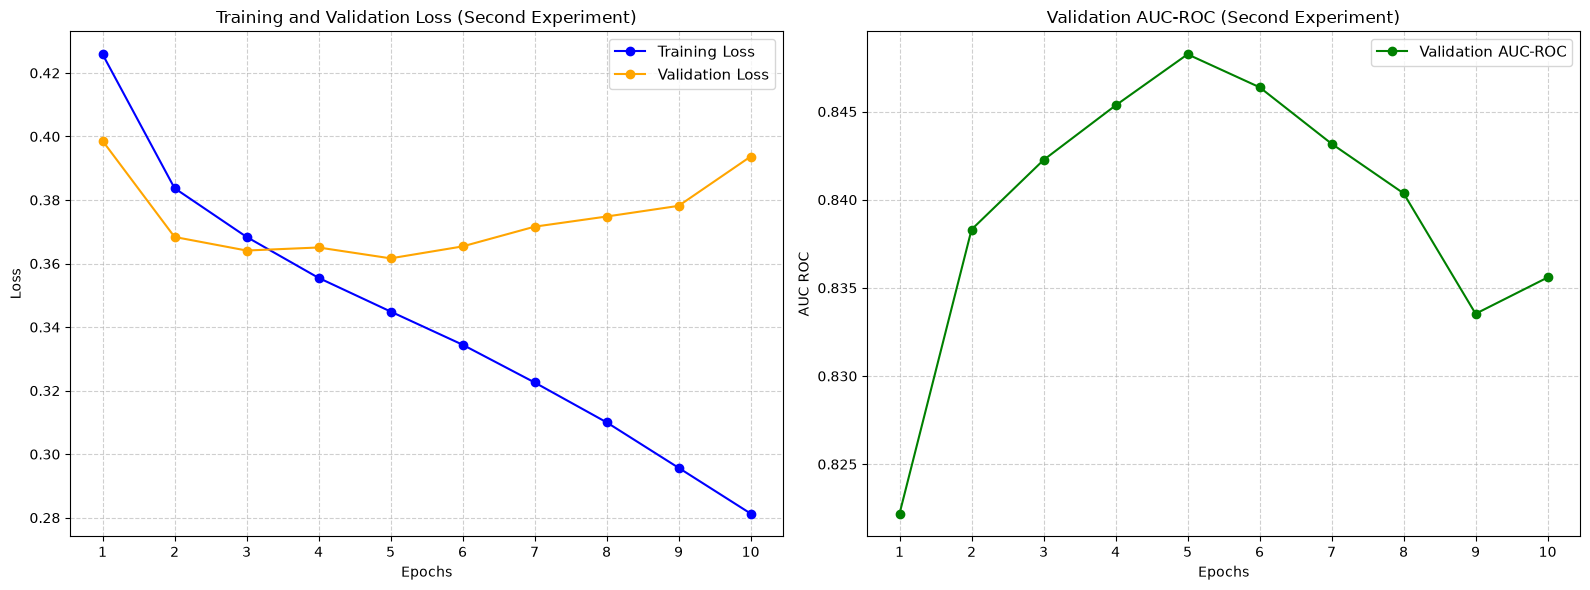

In [66]:
plot_mlflow_metrics(title="Second Experiment", run_id = "71a7d9170b344428b9b50514308aaee5")

The blue line Training loss goes down continuously, which means the model keeps learning the training photos better and better. However the validation loss line hits its lowest point at epoch 5 and then starts going straight up. This indicates sign of overfitting. After epoch 5, the model stopped looking for general medical features and simply started memorizing the training images.
The green line of Validation AUC-ROC matches the loss behavior perfectly. The model reaches its highest accuracy score of 0.8483 at epoch 5. After this point, because of the overfitting the accuracy drops down significantly.

In [66]:
mlflow.end_run()

## Model test

In [67]:
model_v2 = PeftModel.from_pretrained(base_model_v2, "./final_lora_weights")

C:\Users\Petar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\peft\tuners\tuners_utils.py:305: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [68]:
checkpoint = torch.load("./checkpoints_project/best_model.pt", map_location=device)

In [69]:
model_v2.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

In [70]:
model_v2.to(device)

PeftModel(
  (base_model): LoraModel(
    (model): ConvNeXt(
      (stem): Sequential(
        (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
        (1): LayerNorm2d((128,), eps=1e-06, elementwise_affine=True)
      )
      (stages): Sequential(
        (0): ConvNeXtStage(
          (downsample): Identity()
          (blocks): Sequential(
            (0): ConvNeXtBlock(
              (conv_dw): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128)
              (norm): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
              (mlp): GlobalResponseNormMlp(
                (fc1): lora.Linear(
                  (base_layer): Linear(in_features=128, out_features=512, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.1, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=128, out_features=32, bias=False)
                  )
 

In [71]:
model_v2.eval()

test_true = []
test_pred = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc = "Testing"):
        inputs = batch['pixel_values'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model_v2(inputs)
        if hasattr(outputs, "logits"):
            outputs = outputs.logits
            
        probabilities = torch.sigmoid(outputs)
        
        test_true.append(labels.cpu().numpy())
        test_pred.append(probabilities.cpu().numpy())

Testing: 100%|██████████| 366/366 [01:03<00:00,  5.77it/s]


In [72]:
test_true = np.vstack(test_true)
test_pred = np.vstack(test_pred)

In [73]:
macro_test_auc = roc_auc_score(test_true, test_pred, average = "macro")

In [74]:
print(f"Macro AUC-ROC: {macro_test_auc:.4f}") 

Macro AUC-ROC: 0.8409


In [86]:
test_pred_binary = (test_pred > 0.5).astype(int)

In [94]:
test_rep = classification_report(test_true, test_pred_binary, target_names=diseases, zero_division=0, output_dict=True)

In [95]:
test_rep = pd.DataFrame(test_report).transpose()

In [96]:
test_rep = test_report.round(4)

In [97]:
test_rep

,precision,recall,f1-score,support
Cardiomegaly,0.3207,0.3100,0.3153,300.0
Emphysema,0.3432,0.6992,0.4604,266.0
Effusion,0.4695,0.5779,0.5181,1400.0
Hernia,0.1587,0.4348,0.2326,23.0
Infiltration,0.4275,0.3260,0.3699,2098.0
Mass,0.3331,0.5801,0.4232,755.0
Nodule,0.2900,0.3613,0.3217,728.0
Atelectasis,0.3774,0.3724,0.3749,1195.0
Pneumothorax,0.3079,0.6463,0.4171,605.0
Pleural_Thickening,0.2053,0.2287,0.2164,376.0


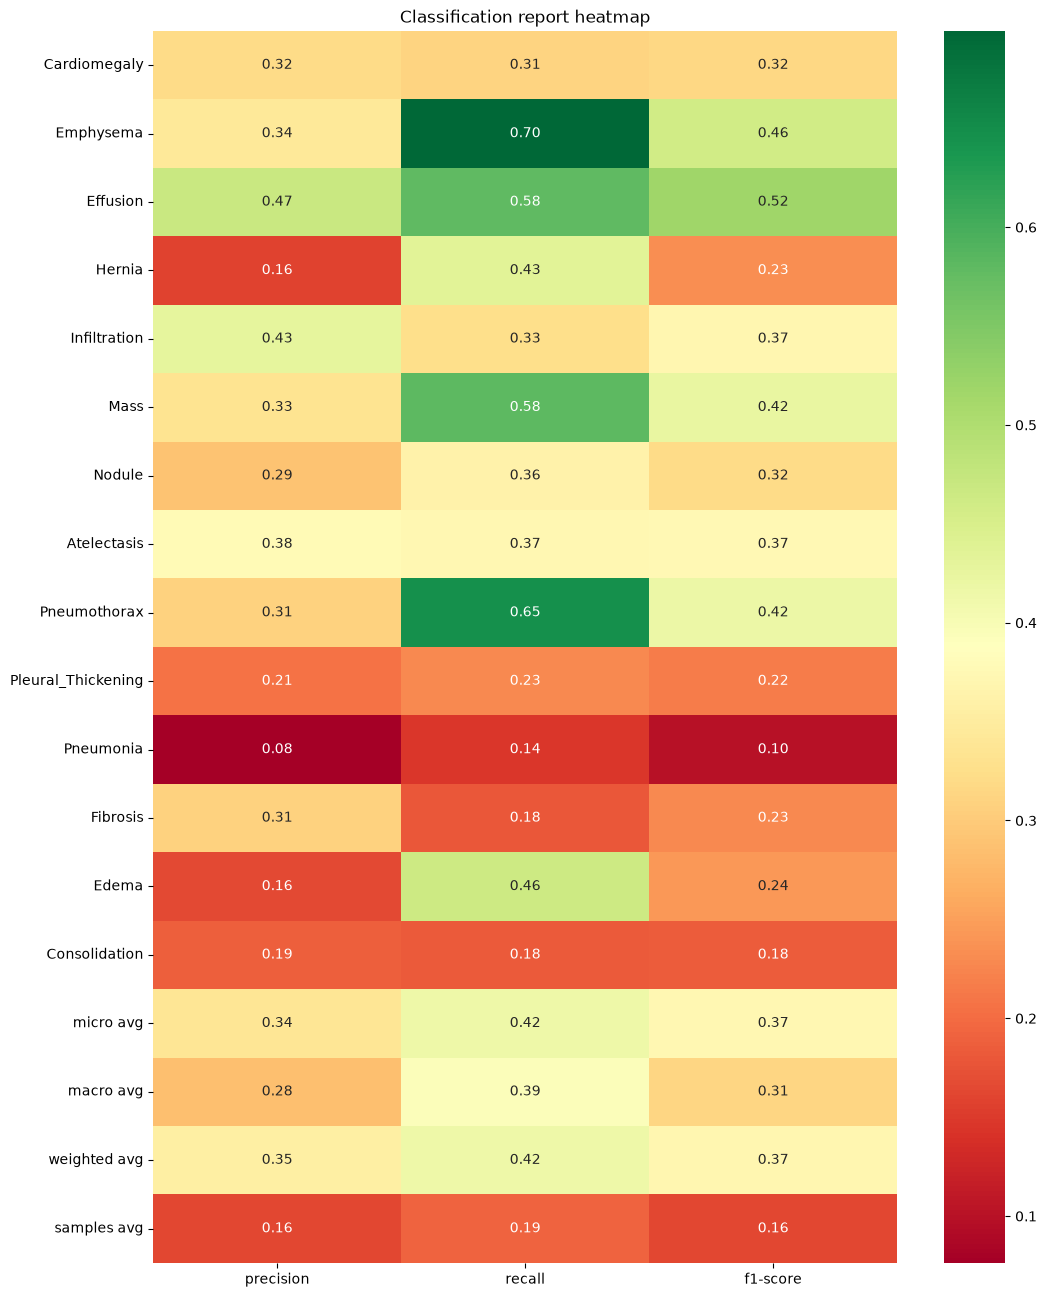

In [101]:
plt.figure(figsize = (12, 16))
sns.heatmap(test_rep[['precision', 'recall', 'f1-score']], annot = True, cmap = 'RdYlGn', fmt = '.2f')
plt.title('Classification report heatmap')
plt.show()

The model achieved a moderate overall performance on the test set with a macro AUC-ROC of 0.8409, but a critically low macro F1-score of only 31%. he performance is identical to the validation set results. This consistency confirms that the model's underperformance is systematic and did not change between datasets. To evaluate the performance I use precision and recall. Precision measures the accuracy of positive predictions - from all predicted cases to have a disease, how many actually have it. Recall measures the model's ability to find all positive instances. While the 84% AUC-ROC indicates a solid potential for general screening, the performance is highly inconsistent across specific classes. For example, even more frequent classes like Effusion (recall: 0.58) and Mass (recall: 0.58) show a weak ability to detect sick patients. The only notable exceptions with higher recall are Emphysema (0.70) and Pneumothorax (0.65), though their precision remains low.\
The heatmap highlights a few severe problem areas where the model struggles. For example, categories like Pneumonia (precision: 0.08, recall: 0.14, f1-score: 0.10) and Hernia (precision: 0.16, recall: 0.43, f1-score: 0.23) show lower performance. This is heavily driven by the massive class imbalance in the dataset, where Hernia makes up only 0.20% and Pneumonia represents 1.20% of the entire data. Since the classification report automatically evaluates the model using a standard 0.50 threshold, it hides the true patterns learned via pos_weight.


## Evaluation and Visualization

In [110]:
print("AUC-ROC performance per disease on the test set")

for i in range(len(diseases)):
    name_disease = diseases[i]
    auc = roc_auc_score(test_true[:, i], test_pred[:, i])
    print(f"{name_disease}: AUC = {auc:.4f}")

AUC-ROC performance per disease on the test set
Cardiomegaly: AUC = 0.8923
Emphysema: AUC = 0.9368
Effusion: AUC = 0.8680
Hernia: AUC = 0.9175
Infiltration: AUC = 0.7146
Mass: AUC = 0.8605
Nodule: AUC = 0.7686
Atelectasis: AUC = 0.8180
Pneumothorax: AUC = 0.8827
Pleural_Thickening: AUC = 0.8158
Pneumonia: AUC = 0.7639
Fibrosis: AUC = 0.8278
Edema: AUC = 0.8957
Consolidation: AUC = 0.8104


The AUC-ROC results show high values across almost all categories, with Emphysema reaching 0.9368, Hernia at 0.9175, and Edema at 0.8957. While these numbers look high, they must be interpreted carefully alongside the previous classification report. In highly imbalanced medical datasets, a high AUC-ROC score doesnt mean the model has high accuracy in making final diagnoses. Instead it indicates that the model successfully learned to rank patients, giving higher probability scores to truly sick individuals compared to the healthy majority. 

## Confusion matrix

In [118]:
#Standard decision threshold for medical diagnosis
threshold = 0.5

In [120]:
print("Where does the model fail?")
print("=" * 50)

for i in range(len(diseases)):
    name_disease = diseases[i]
    
    binary_preds = (test_pred[:, i] > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(test_true[:, i], binary_preds).ravel()
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  #true positive rate / recall
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  #true negative rate
    
    print(f"{name_disease}:")
    print(f" False Negatives (missed patients): {fn} patients")
    print(f" False Positives: {fp} patients")
    print(f" Sensitivity (Recall): {sensitivity:.4f}")
    print(f" Specificity: {specificity:.4f}") #healthy cases
    print("-" * 50)

Where does the model fail?
Cardiomegaly:
  False Negatives (missed patients): 207 patients
  False Positives: 197 patients
  Sensitivity (Recall): 0.3100
  Specificity: 0.9827
--------------------------------------------------
Emphysema:
  False Negatives (missed patients): 80 patients
  False Positives: 356 patients
  Sensitivity (Recall): 0.6992
  Specificity: 0.9688
--------------------------------------------------
Effusion:
  False Negatives (missed patients): 591 patients
  False Positives: 914 patients
  Sensitivity (Recall): 0.5779
  Specificity: 0.9111
--------------------------------------------------
Hernia:
  False Negatives (missed patients): 13 patients
  False Positives: 53 patients
  Sensitivity (Recall): 0.4348
  Specificity: 0.9955
--------------------------------------------------
Infiltration:
  False Negatives (missed patients): 1414 patients
  False Positives: 916 patients
  Sensitivity (Recall): 0.3260
  Specificity: 0.9044
---------------------------------------

This error analysis shows exactly how the standard 0.50 threshold forces classification errors, despite the use of pos_weight during training. The Specificity is very high (mostly above 90-95%), which means the model is excellent at finding healthy cases. However, the results also reveals critical weaknesses in clinical deployment.\
The biggest danger is the high number of False Negatives (missed patients). For example, the model missed 1414 real cases of Infiltration and 591 cases of Effusion. In a real-world hospital, sending hundreds of sick patients home without a diagnosis presents an unacceptable risk. Simultaneously, the model suffers from a high rate of False Positives. It generated 916 false alarms for Infiltration and 877 for Mass. This happens because the model easily mistakes normal bone structures or shadows for real diseases. \
In conclusion, using a fixed 0.50 threshold doesnt work for this imbalanced chest X-ray dataset. To fix these errors in the future, we need to find better, individual thresholds for each specific disease instead of using 0.50 for everything. This will help reduce the number of missed patients for dangerous conditions.


## Confusion matrix Visualization

In [123]:
binary_preds = (test_pred > threshold).astype(int)

In [124]:
true_argmax = np.argmax(test_true, axis=1)
pred_argmax = np.argmax(test_pred, axis=1)

In [125]:
cm = confusion_matrix(true_argmax, pred_argmax, normalize='true')

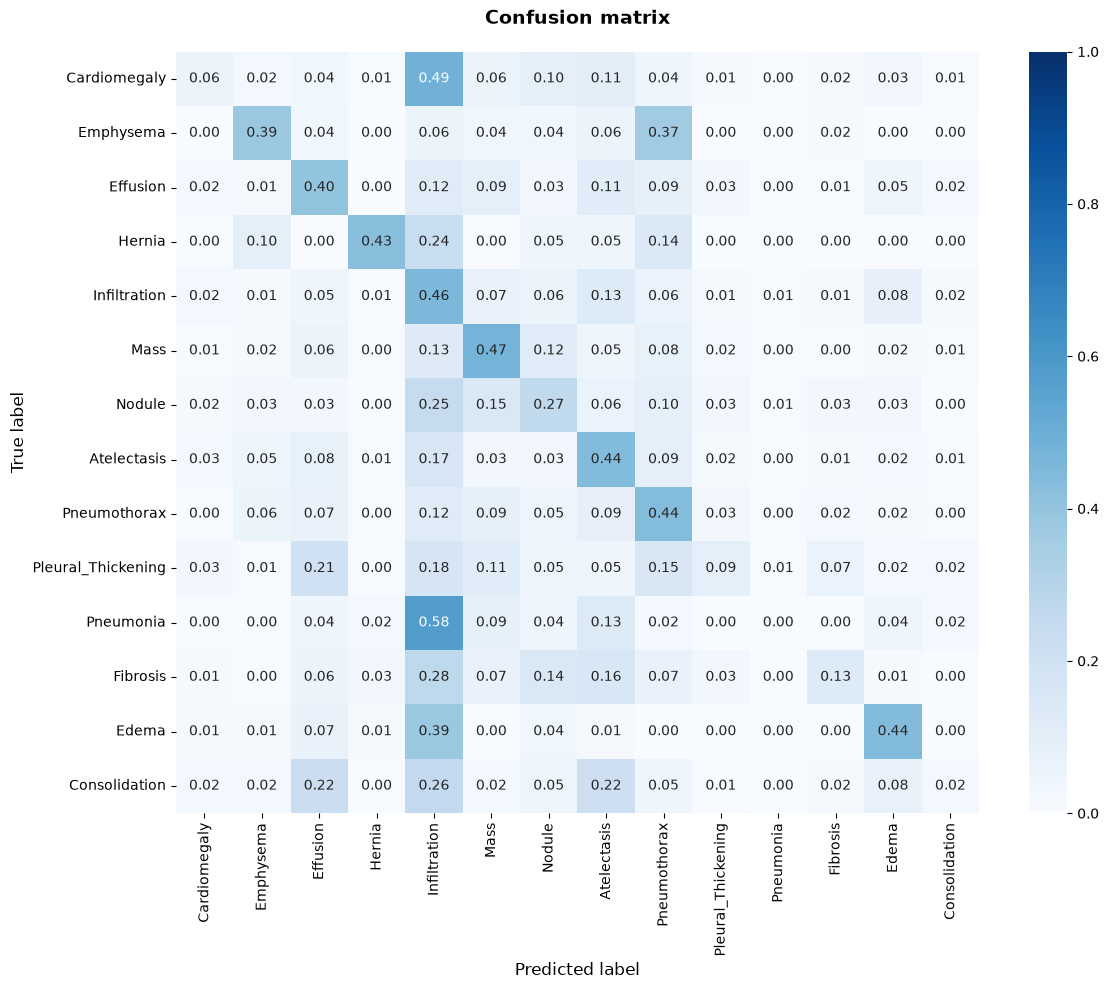

In [127]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    cm, 
    annot = True,            
    fmt = ".2f",             
    cmap="Blues",          
    xticklabels = diseases,  
    yticklabels = diseases,  
    vmin = 0, vmax = 1         
)

plt.title("Confusion matrix", fontsize = 14, fontweight = 'bold', pad = 20)
plt.ylabel("True label", fontsize = 12)
plt.xlabel("Predicted label", fontsize = 12)

plt.xticks(rotation = 90)
plt.yticks(rotation = 0)

plt.tight_layout()
plt.show()

The normalized confusion matrix provides a clear explanation for the model's performance limitations. Instead of a strong, dark diagonal line which represents correct predictions, the matrix shows that the model heavily confuses different pathologies with the most common class in the dataset. \
The most significant finding is the vertical alignment in the **Infiltration** column. Because Infiltration is the dominant class in the dataset, the model developed a strong bias toward it. For example when a patient actually has *Pneumonia*, the model misclassifies it as Infiltration in **58%** of the cases. Similarly, **49%** of *Cardiomegaly* cases and **39%** of *Edema* cases are incorrectly predicted as Infiltration. \
The true diagonal values remain mostly low (ranging between 0.39 and 0.44 for most active classes). This indicates that the architecture struggle to find unique visual boundaries for specific diseases. Since many lung conditions look like similar blurry white shadows on an X-ray, the model defaults to predicting the most frequent class whenever it is uncertain.

## Qualitative evaluation: Visual examples

In [133]:
def visualize_model_predictions(model_v2, test_loader, diseases, device, num_images=4):
    
    model_v2.eval()
    
    batch = next(iter(test_loader))
    inputs = batch['pixel_values'].to(device)
    labels = batch['labels']
    
    if torch.is_tensor(labels):
        labels = labels.cpu().numpy()
    elif isinstance(labels, list):
        labels = np.array(labels)
        
    with torch.no_grad():
        outputs = model_v2(inputs)
        if hasattr(outputs, "logits"):
            outputs = outputs.logits
        probabilities = torch.sigmoid(outputs).cpu().numpy()
        
    plt.figure(figsize=(18, 10))
    
    for idx in range(min(num_images, len(inputs))):
        plt.subplot(1, num_images, idx + 1)
        
        img = inputs[idx].cpu().numpy()
        if img.ndim == 3:
            img = np.transpose(img, (1, 2, 0))
        img = (img - img.min()) / (img.max() - img.min() + 1e-8) #adding 1e-8 to prevent division by zero
        
        plt.imshow(img, cmap ='bone')
        plt.axis('off')
        
        true_diseases = [diseases[i] for i in range(14) if labels[idx][i] == 1]
        
        if not true_diseases:
            true_diseases = ["Healthy"]
            
        pred_diseases = [f"{diseases[i]} ({probabilities[idx][i] * 100:.0f}%)" for i in range(14) if probabilities[idx][i] > 0.5]
        if not pred_diseases:
            pred_diseases = ["Healthy"]
            
        title_text = f"True diagnosis: {', '.join(true_diseases)}\nPrediction: {', '.join(pred_diseases)}"
        
        is_correct = set([d.split()[0] for d in pred_diseases if d != "Healthy"]) == set([d for d in true_diseases if d != "Healthy"])
        title_color = 'green' if is_correct else 'red'
        
        plt.title(title_text, fontsize=10, color = title_color, pad = 10)
        
    plt.tight_layout()
    plt.show()

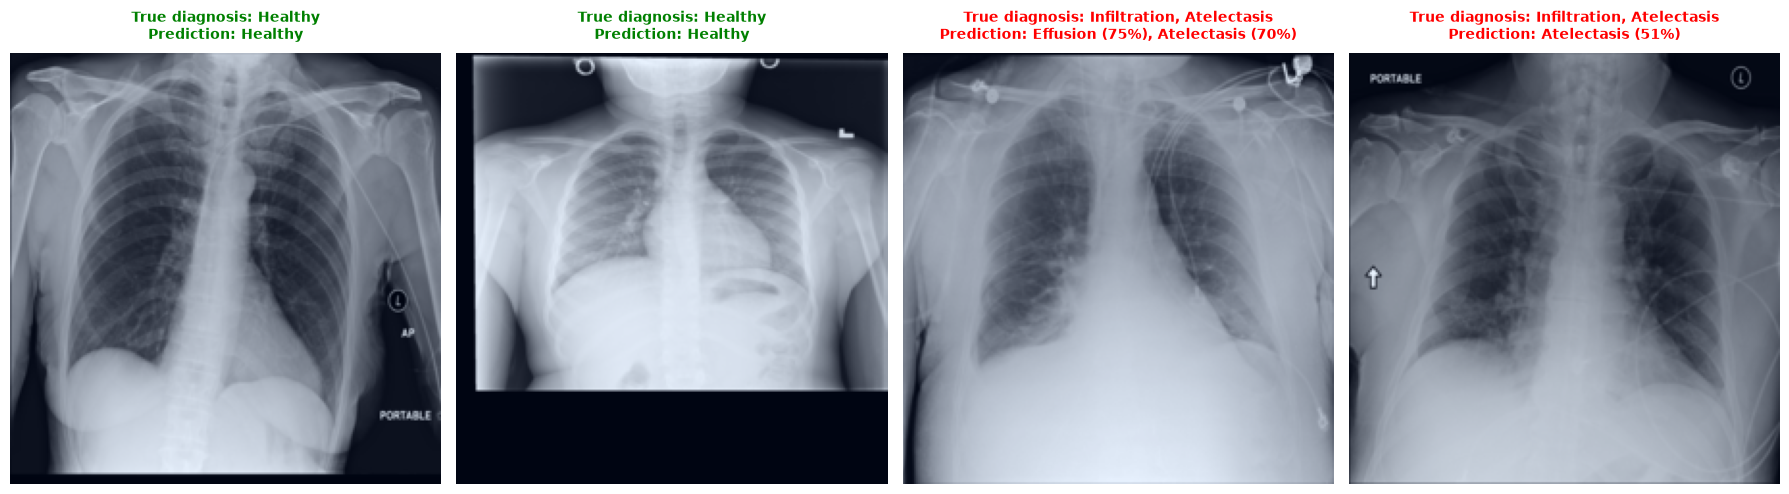

In [131]:
visualize_model_predictions(model_v2, test_loader, diseases, device, num_images = 4)

This qualitative analysis provides a visual demonstration of the model's performance on the test set by comparing the true diagnosis with the model's predictions. For completely healthy patients, the model matches the true label, confirming its strong ability to identify true negative cases. For patients with multiple diseases, the model struggles. It either misses conditions entirely such as skipping Infiltration or confuses them such as predicting Effusion instead of Infiltration due to the identical appearance of white shadows on chest X-rays.

## Saliency map

The Saliency map is an explainable AI (XAI) method used to show where the model looks when making a decision. 
The method calculates gradients to see which specific pixels on the X-ray image affect the model's prediction the most.
It highlights these important pixels on a dark background. It helps verify if the AI is looking at real medical problems (like a lung shadow or an enlarged heart) or if it is getting distracted by background noise and imaging artifacts.

In [75]:
def plot_all_diseases_per_patient(model_v2, test_loader, diseases, device, num_samples=2):
    model_v2.eval()
    found_samples = 0
    
    for batch in test_loader:
        if found_samples >= num_samples:
            break
            
        inputs = batch['pixel_values'].to(device)
        labels = batch['labels'].cpu().numpy()
        
        with torch.no_grad():
            outputs = model_v2(inputs)
            if hasattr(outputs, "logits"):
                outputs = outputs.logits
            probabilities = torch.sigmoid(outputs).cpu().numpy()
            
        for idx in range(len(inputs)):
            if found_samples >= num_samples:
                break
                
            true_class_indices = [i for i in range(14) if labels[idx][i] == 1]
            
            if len(true_class_indices) >= 2:
                all_true_names = [diseases[i] for i in true_class_indices]
                
                num_plots = 1 + len(true_class_indices)
                fig, axes = plt.subplots(1, num_plots, figsize=(4 * num_plots, 4))
                
                orig_img = batch['pixel_values'][idx].cpu().numpy()
                if orig_img.ndim == 3:
                    orig_img = np.transpose(orig_img, (1, 2, 0))
                orig_img = (orig_img - orig_img.min()) / (orig_img.max() - orig_img.min() + 1e-8)
                
                axes[0].imshow(orig_img, cmap='bone')
                axes[0].set_title(f"Patient {found_samples+1}\nTrue Labels:\n{', '.join(all_true_names)}", fontsize = 9)
                axes[0].axis('off')
                
                for p_idx, target_class_idx in enumerate(true_class_indices):
                    ax = axes[p_idx + 1]
                    name_disease = diseases[target_class_idx]
                    ai_conf = probabilities[idx][target_class_idx] * 100
                    
                    single_input = inputs[idx:idx+1].clone().detach()
                    single_input.requires_grad = True
                    
                    outputs_single = model_v2(single_input)
                    if hasattr(outputs_single, "logits"):
                        outputs_single = outputs_single.logits
                        
                    score = outputs_single[0, target_class_idx]
                    
                    if single_input.grad is not None:
                        single_input.grad.zero_()
                        
                    score.backward()
                    
                    saliency, _ = torch.max(single_input.grad.data.abs(), dim=1)
                    saliency = saliency.reshape(saliency.shape[-2], saliency.shape[-1]).cpu().numpy()
                    
                    if saliency.max() != 0:
                        saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)

                    pos = ax.imshow(saliency, cmap='hot')
                    ax.set_title(f"Model prediction:\n{name_disease} ({ai_conf:.0f}%)", fontsize = 9)
                    ax.axis('off')
                    fig.colorbar(pos, ax = ax, fraction = 0.046, pad = 0.04)
                
                plt.tight_layout()
                plt.show()
                found_samples += 1

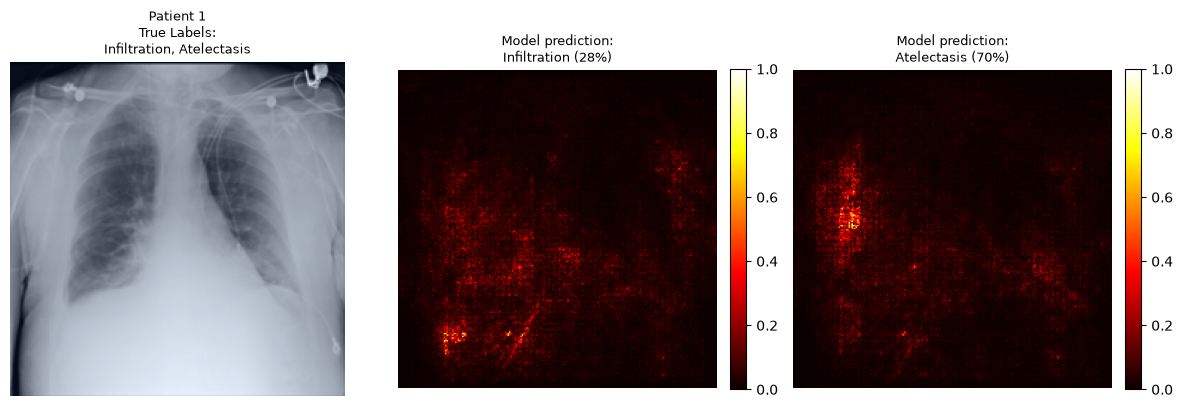

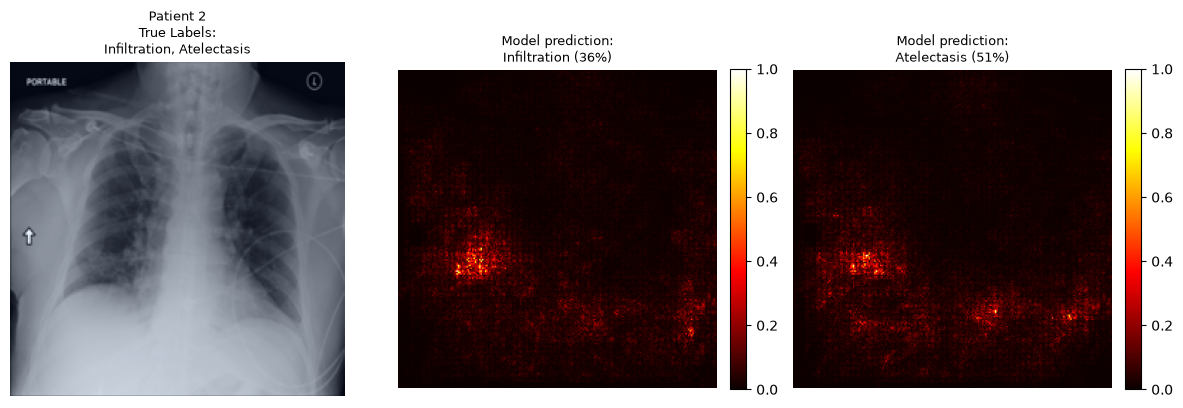

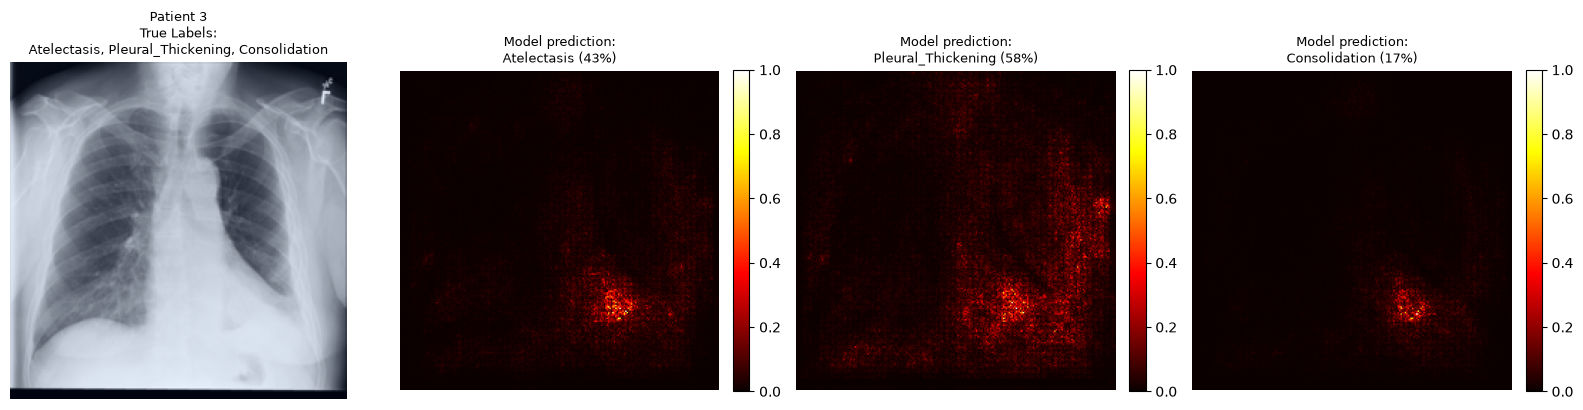

In [76]:
plot_all_diseases_per_patient(model_v2, test_loader, diseases, device, num_samples = 3)

This multi-label saliency visualization confirms that the model's low F1-scores are a limitation of the static 0.50 threshold, rather than a failure of the architecture itself.\
For example, in Patient 1, the model highlights one specific region for Infiltration (28%) and moves its focus to a different area for Atelectasis (70%). While we cant be 100% sure that these areas are medically accurate without a doctor's confirmation, it indicates that the model is not just looking at the same spot for every disease. \
The main problem is the strict 0.50 threshold. For rarer diseases like Infiltration, the model's confidence is lower (28%). Because this is below 50%, our previous code completely hid these results and made the model look blind. This graph shows that the model captures patterns for secondary diseases but they are too weak to pass the 50% cutoff. In the future, we need to test individual thresholds for each disease.

##  Quantitative error analysis

In [79]:
false_negatives = []
false_positives = []

for t in thresholds:
    binary_preds = (test_pred[:, disease_idx] > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(test_true[:, disease_idx], binary_preds).ravel()
    false_negatives.append(fn)
    false_positives.append(fp)

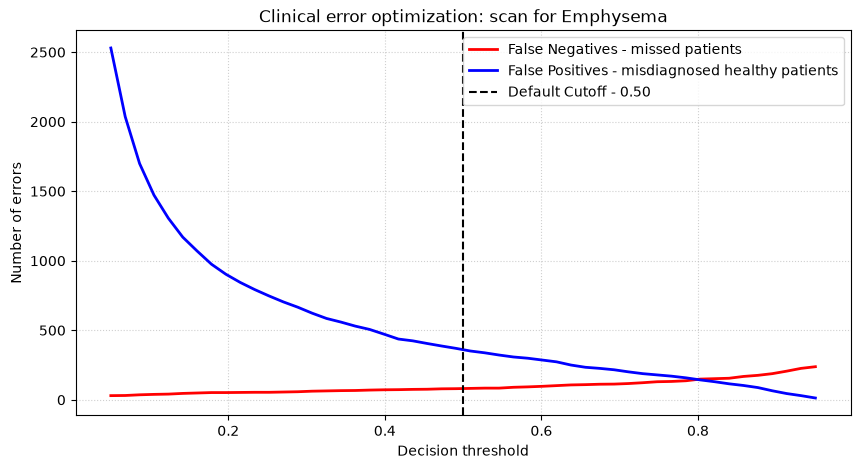

In [80]:
plt.figure(figsize = (10, 5))
plt.plot(thresholds, false_negatives, label = 'False Negatives - missed patients', color = 'red', linewidth = 2)
plt.plot(thresholds, false_positives, label='False Positives - misdiagnosed healthy patients', color = 'blue', linewidth = 2)
plt.axvline(x = 0.5, color = 'black', linestyle = '--', label = 'Default Cutoff - 0.50')
plt.title(f"Clinical error optimization: scan for {diseases[disease_idx]}", fontsize = 12)
plt.xlabel("Decision threshold")
plt.ylabel("Number of errors")
plt.legend()
plt.grid(True, linestyle = ':', alpha = 0.6)

plt.show()

The model uses the standard 0.50 threshold, represented by the black dashed line. At this point the blue line is very high. This means the model makes too many False Positives, which means it diagnoses around 400 healthy patients as sick. This is why the Precision and F1-score for Emphysema looked bad in our report.\
The red line is very low at 0.50. This means the model is excellent at not missing real sick patients with very few False Negatives.\
The graph shows that we shouldn't use 0.50 for every disease. The perfect balance is where the red and blue lines cross around 0.75 - 0.80. If we move the threshold to 0.75 in the future, the false diagnoses will drop close to zero, and the model will become much more accurate.

## Confidence distribution analysis

In [82]:
disease_idx = diseases.index('Emphysema')

In [83]:
probs_healthy = test_pred[test_true[:, disease_idx] == 0, disease_idx] * 100
probs_sick = test_pred[test_true[:, disease_idx] == 1, disease_idx] * 100

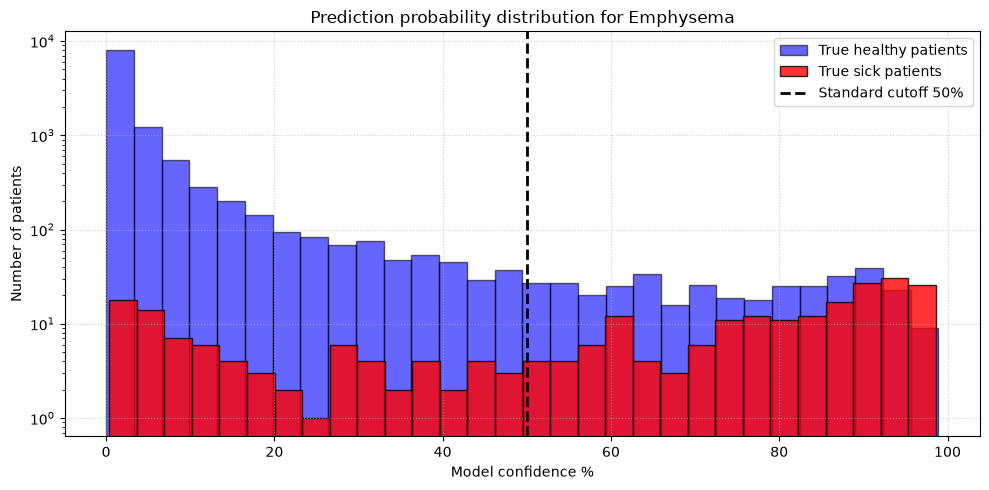

In [88]:
plt.figure(figsize = (10, 5))

plt.hist(probs_healthy, bins = 30, alpha = 0.6, label = 'True healthy patients', color = 'blue', edgecolor = 'black')
plt.hist(probs_sick, bins = 30, alpha = 0.8, label = 'True sick patients', color = 'red', edgecolor = 'black')

plt.axvline(x = 50, color = 'black', linestyle = '--', linewidth = 2, label = 'Standard cutoff 50%')

plt.title(f"Prediction probability distribution for {diseases[disease_idx]}", fontsize = 12)
plt.xlabel("Model confidence %")
plt.ylabel("Number of patients")
plt.yscale('log')
plt.legend()
plt.grid(True, linestyle = ':', alpha = 0.6)

plt.tight_layout()
plt.show()

This graph shows the exact confidence percentages that the model gives to healthy and sick patients for Emphysema. We use a log scale on the vertical axis because there are thousands of healthy cases.\
The vast majority of healthy patients correctly receive very low confidence scores close to 0-25%. However, because there are thousands of healthy people in the dataset, a small part of this blue distribution crosses the 50% line. This creates the 400 misdiagnosed healthy patients we saw in the previous graph.\
The true sick patients are grouped mostly in the higher percentage range 60-100%, showing that the model correctly identifies them when it is confident.\
The high error rate isn't caused by random guessing, but by the fact that the 50% cutoff line is placed incorrectly for this disease's distribution.


## Conclusion

This project provided a complete evaluation of the fine-tuned ConvNeXt-V2 architecture for multi-label chest X-ray classification. By combining global metrics, error analysis, and visual explanations, we discovered the true strengths and limitations of the trained model.\
The model achieved a solid overall performance with a macro AUC-ROC of 0.8409. This high score shows that the network developed a correct medical intuition and successfully learned to rank patients by giving higher probabilities to sick individuals. However, the macro F1-score remained low at 31%. Although class imbalance was actively addressed during training using a custom pos_weight tensor, the standard 0.50 decision threshold is still mathematically incorrect for the resulting weighted probability distribution.\
We found that architectural scaling using Parameter-Efficient Fine-Tuning (PEFT) has strict limits. Doubling the LoRA capacity from rank r = 16 to r = 32 and adding adapters to depthwise convolutions failed to break the accuracy ceiling. Instead, the higher model capacity caused severe overfitting after epoch 5 in the train set, where the network simply memorized training images rather than learning general medical features for rare conditions.\
The saliency mapping and confidence distribution analysis shows that the model's low F1-scores are a limitation of the static 0.50 threshold rather than a structural failure of the architecture itself. Saliency maps indicate that the model shifts its attention to distinct, medically relevant anatomical regions for secondary diseases. However, because secondary and rare conditions generate weaker visual patterns that fall below the 50% cutoff, these valid feature captures were completely hidden in practice, making the model appear blind to secondary diagnoses.\
In the quantitative error analysis we use Emphysema as a case study. It illustrated the clinical risk of a unified threshold. The model missed too many real sick patients (False Negatives) and generated 400 false alarms (False Positives) for healthy people due to normal bone shadows. By tracking the error optimization curves, the perfect balance for Emphysema was identified at a threshold of 0.75 - 0.80, where false positives drop close to zero without severely increasing missed cases.\
To realize the full clinical potential of this model, future work must move away from the fixed 0.50 threshold rule. Implementing class-specific, dynamic threshold tuning will instantly reduce the number of high-risk False Negatives for life-threatening conditions. Additionally, testing advanced data-balancing techniques, such as focal loss or targeted data augmentation, is essential to mitigate the remaining bias toward dominant dataset classes.

## Sources

* ConvNeXt-V2: Woo S., et al. "ConvNeXt V2: Co-designing and Scaling ConvNets with Masked Autoencoders." arXiv preprint arXiv:2301.00808, 2023.
* LoRA (Low-Rank Adaptation): Hu E. J., et al. "LoRA: Low-Rank Adaptation of Large Language Models." arXiv preprint arXiv:2106.09685, 2021.
* PyTorch BCEWithLogitsLoss: PyTorch Core Team. Binary Cross Entropy with Logits Loss documentation. https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html
* https://huggingface.co/blog/peft
